In [ ]:
from tensorflow.keras.datasets import mnist, cifar10

# MNIST
(X_train_mnist, y_train_mnist), (X_test_mnist, y_test_mnist) = mnist.load_data()

# CIFAR-10
(X_train_cifar, y_train_cifar), (X_test_cifar, y_test_cifar) = cifar10.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step


In [ ]:
print("MNIST Train Shape:", X_train_mnist.shape)
print("MNIST Test Shape:", X_test_mnist.shape)

print("MNIST dtype:", X_train_mnist.dtype)
print("MNIST value range:", X_train_mnist.min(), X_train_mnist.max())

MNIST Train Shape: (60000, 28, 28)
MNIST Test Shape: (10000, 28, 28)
MNIST dtype: uint8
MNIST value range: 0 255


In [ ]:
print("CIFAR Train Shape:", X_train_cifar.shape)
print("CIFAR Test Shape:", X_test_cifar.shape)

print("CIFAR dtype:", X_train_cifar.dtype)
print("CIFAR value range:", X_train_cifar.min(), X_train_cifar.max())

CIFAR Train Shape: (50000, 32, 32, 3)
CIFAR Test Shape: (10000, 32, 32, 3)
CIFAR dtype: uint8
CIFAR value range: 0 255


task -1 p-1

MNIST is a database of hand-written digits ranging from 0 to 9. The images in this dataset are grayscale with dimensions of 28 × 28 pixels. This database is primarily used for simple image recognition purposes.

CIFAR-10 is a database containing colored images belonging to 10 different categories such as airplanes, cars, birds, cats, etc. The images in this database have dimensions of 32 × 32 pixels with 3 RGB color channels.

Hence, we can conclude that MNIST is simpler compared to CIFAR-10.

task - 1 p- 2

Normalization of images refers to scaling down of the values of pixels to a limited range, mostly from 0 to 1.

For MNIST and CIFAR-10 data sets, pixel values are scaled from 0 to 255. Dividing all values by 255.0 will scale them to the range 0 to 1.

It is critical since:

It speeds up the training process.
It improves stability of the training process.
Avoids the problem of being dominated by high values.

In [ ]:
# Task 1 - Problem 3
# Preprocessing Pipeline

import numpy as np
import tensorflow as tf

# setting seed
np.random.seed(42)
tf.random.set_seed(42)

# Normalize data
print("Before normalization:")
print("MNIST shape:", X_train_mnist.shape)
print("MNIST range:", X_train_mnist.min(), "to", X_train_mnist.max())

X_train_mnist = X_train_mnist.astype(np.float32) / 255.0
X_test_mnist  = X_test_mnist.astype(np.float32) / 255.0

X_train_cifar = X_train_cifar.astype(np.float32) / 255.0
X_test_cifar  = X_test_cifar.astype(np.float32) / 255.0

print("\nAfter normalization:")
print("MNIST range:", X_train_mnist.min(), "to", X_train_mnist.max())

# Reshape MNIST
X_train_mnist = X_train_mnist.reshape(-1, 28, 28, 1)
X_test_mnist  = X_test_mnist.reshape(-1, 28, 28, 1)

print("\nAfter reshape:")
print("MNIST shape:", X_train_mnist.shape)
print("CIFAR shape:", X_train_cifar.shape)

# One-hot encoding
def one_hot(labels):
    labels = labels.flatten()
    result = np.zeros((len(labels), 10))

    for i in range(len(labels)):
        result[i][labels[i]] = 1

    return result
y_train_mnist = one_hot(y_train_mnist)
y_test_mnist  = one_hot(y_test_mnist)

y_train_cifar = one_hot(y_train_cifar)
y_test_cifar  = one_hot(y_test_cifar)

print("\nAfter encoding:")
print("MNIST labels shape:", y_train_mnist.shape)
print("Example:", y_train_mnist[0])

print("\nFinal shapes:")
print("MNIST images:", X_train_mnist.shape)
print("MNIST labels:", y_train_mnist.shape)
print("CIFAR images:", X_train_cifar.shape)
print("CIFAR labels:", y_train_cifar.shape)

Before normalization:
MNIST shape: (60000, 28, 28)
MNIST range: 0 to 255

After normalization:
MNIST range: 0.0 to 1.0

After reshape:
MNIST shape: (60000, 28, 28, 1)
CIFAR shape: (50000, 32, 32, 3)

After encoding:
MNIST labels shape: (60000, 10)
Example: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]

Final shapes:
MNIST images: (60000, 28, 28, 1)
MNIST labels: (60000, 10)
CIFAR images: (50000, 32, 32, 3)
CIFAR labels: (50000, 10)


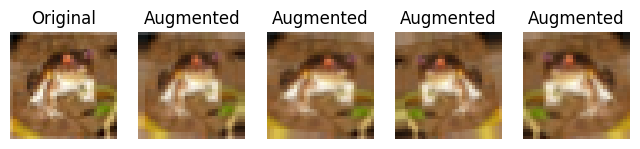

In [ ]:
# Task 1 - Problem 4
# Data Augmentation

from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

sample_image = X_train_cifar[0]

plt.figure(figsize=(8,4))

# original
plt.subplot(1,5,1)
plt.imshow(sample_image)
plt.title("Original")
plt.axis("off")

# augmented
for i in range(4):
    aug_image = datagen.random_transform(sample_image)

    plt.subplot(1,5,i+2)
    plt.imshow(aug_image)
    plt.title("Augmented")
    plt.axis("off")

plt.show()

Q1. What does the channel dimension represent?

The channel dimension (C) represents the number of feature maps or color channels in an image. In a grayscale image, C = 1 because there is only one intensity channel. In an RGB image, C = 3 representing Red, Green, and Blue channels. In CNNs, this dimension allows the model to process multiple types of information per pixel.


Q2. Data loading strategies for large images

To avoid memory issues when training on large images:

1. **Batch loading (mini-batching)**: Instead of loading the entire dataset, data is loaded in small batches during training. This reduces memory usage significantly.

2. **Image resizing / downsampling**: Reducing image resolution decreases memory and computation requirements.

3. **Data generators / streaming**: Images are loaded on-the-fly from disk rather than storing all in RAM.

These techniques help manage memory efficiently while training CNNs.


Q3. Why test normalization using test statistics is wrong?

Using mean and standard deviation from the test set causes data leakage. The model indirectly gains information about test data, which violates the principle of unbiased evaluation. Instead, normalization parameters should be computed from the training set and applied to both training and test data.



In [ ]:
# Task 2 - Problem 1
# manual convolution using numpy

import numpy as np

def conv2d(image, kernel, stride=1, padding=0):
    if padding > 0:
        image = np.pad(image, padding)

    h, w = image.shape
    kh, kw = kernel.shape

    out_h = int((h - kh) / stride) + 1
    out_w = int((w - kw) / stride) + 1

    output = np.zeros((out_h, out_w))

    for i in range(out_h):
        for j in range(out_w):

            r = i * stride
            c = j * stride

            patch = image[r:r+kh, c:c+kw]
            output[i, j] = np.sum(patch * kernel)

    return output

image = np.array([
    [3,1,0,2,4],
    [1,5,3,2,1],
    [0,2,6,4,3],
    [2,3,1,5,2],
    [1,0,2,3,4]
], dtype=np.float32)

kernel = np.array([
    [-1,0,1],
    [-2,0,2],
    [-1,0,1]
], dtype=np.float32)
result = conv2d(image, kernel, stride=1, padding=0)

print("Output:")
print(result)
print("Shape:", result.shape)

Output:
[[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]
Shape: (3, 3)


Task - 2 p -1

In this problem, convolution was implemented manually using NumPy.
A 5×5 input image and a 3×3 Sobel-X kernel were used.

The kernel was slid over the image, and at each position, element-wise multiplication was performed followed by summation to get the output value.

The output feature map obtained had a smaller size compared to the input image because no padding was used.

This operation helps in detecting features such as edges in the image.

Task - 2 P -2

(a) Input = 28×28, Kernel = 5×5, Padding = 0, Stride = 1  
Output = (28 − 5 + 0) / 1 + 1 = 24  
So, output size = 24 × 24  

(b) Input = 28×28, Kernel = 3×3, Padding = 1, Stride = 1  
Output = (28 − 3 + 2×1) / 1 + 1 = 28  
So, output size = 28 × 28  

(c) Input = 32×32, Kernel = 3×3, Padding = 0, Stride = 2  
Output = (32 − 3 + 0) / 2 + 1 = 15  
So, output size = 15 × 15  

(d) First layer:  
Input = 32×32, Kernel = 3×3, Padding = 1, Stride = 1  
Output = (32 − 3 + 2×1) / 1 + 1 = 32  

Second layer:  
Input = 32×32, Kernel = 3×3, Padding = 0, Stride = 1  
Output = (32 − 3 + 0) / 1 + 1 = 30  

Final output size = 30 × 30

In [ ]:
# Task 2 - Problem 3
# LeNet model

import tensorflow as tf
from tensorflow.keras import layers, Sequential

model = Sequential()

model.add(layers.Conv2D(6, (5,5), input_shape=(28,28,1))) # Layer -1
model.add(layers.Activation('tanh'))
model.add(layers.AveragePooling2D(2,2))

model.add(layers.Conv2D(16, (5,5))) # Layer -2
model.add(layers.Activation('tanh'))
model.add(layers.AveragePooling2D(2,2))

# flatten + dense
model.add(layers.Flatten())
model.add(layers.Dense(120, activation='tanh'))
model.add(layers.Dense(84, activation='tanh'))
model.add(layers.Dense(10, activation='softmax'))

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 24, 24, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

Task - 2 P - 3

LeNet-5 is a convolutional neural network designed for image classification tasks such as handwritten digit recognition.

The architecture consists of convolution layers followed by activation (tanh), average pooling, and fully connected layers.

The first convolution layer uses 5×5 filters with 6 output channels. The parameter count is calculated using the formula:
(K × K × C_in + 1) × C_out

So, (5 × 5 × 1 + 1) × 6 = (25 + 1) × 6 = 156 parameters.

Average pooling was used in LeNet-5 because it smooths the feature maps. However, modern CNNs use max pooling because it preserves stronger features and gives better performance.

In [ ]:
# Task 2 - Problem 4
# my simple cnn model

import tensorflow as tf
from tensorflow.keras import layers, Sequential

model = Sequential()

model.add(layers.Conv2D(16, (3,3), input_shape=(32,32,3))) #block - 1
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(32, (3,3))) #block - 2
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64, (3,3))) #block - 3
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(10, activation='softmax'))

model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 30, 30, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 30, 30, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 15, 15, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 13, 13, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 13, 13, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,130 (160.66 KB)

 Trainable params: 40,906 (159.79 KB)

 Non-trainable params: 224 (896.00 B)

Task - 2 P - 4

The custom CNN model was designed with three convolutional blocks. Each block contains Conv2D, Batch Normalization, ReLU activation, and MaxPooling layers.

The number of filters is increased gradually (32 → 64 → 128) so that the model can learn more complex features at deeper layers.

Batch Normalization is used to make training stable and faster. MaxPooling reduces the size of feature maps and helps in extracting important features.

A Dense layer is used at the end for classification, and Dropout is added to reduce overfitting.

Overall, the architecture is simple but effective for CIFAR-10 classification.

Q1. 3×3 vs 5×5 convolution

Two stacked 3×3 convolutions use fewer parameters than one 5×5 convolution.

Parameters:
5×5 → 25 weights per filter  
Two 3×3 → 9 + 9 = 18 weights

Thus, 3×3 stacks are more parameter-efficient.

Advantages:
- More non-linearity (due to activation between layers)
- Better feature extraction
- Reduced computation


Q2. Role of Batch Normalization

Batch Normalization normalizes activations to stabilize training. It is usually placed after convolution and before activation.

Benefits:
- Faster convergence
- Reduced internal covariate shift
- Allows higher learning rates
- Acts as regularization

Q3. Global Average Pooling vs Flatten

GlobalAveragePooling reduces each feature map to a single value by averaging, resulting in fewer parameters. Flatten converts all spatial values into a large vector, increasing parameters.

Replacing GAP with Flatten:
- Increases parameters significantly
- May cause overfitting
- Retains spatial details but less efficient

Epoch 1/2
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.7700 - loss: 0.9721 - val_accuracy: 0.9143 - val_loss: 0.4196
Epoch 2/2
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.9160 - loss: 0.3656 - val_accuracy: 0.9452 - val_loss: 0.2354
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9393 - loss: 0.2633
acc: 0.939300000667572


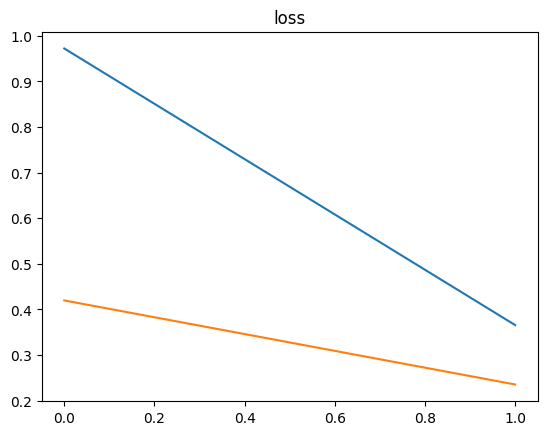

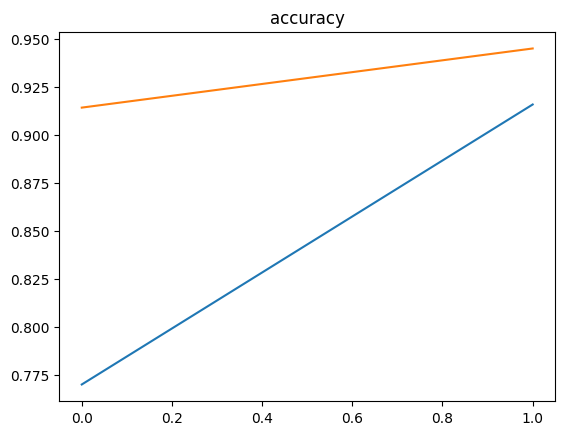

In [ ]:
# task 3 problem 1

import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import SGD

model = Sequential()

model.add(layers.Conv2D(6, (5,5), input_shape=(28,28,1)))
model.add(layers.Activation('tanh'))
model.add(layers.AveragePooling2D(2,2))

model.add(layers.Conv2D(16, (5,5)))
model.add(layers.Activation('tanh'))
model.add(layers.AveragePooling2D(2,2))

model.add(layers.Flatten())
model.add(layers.Dense(120, activation='tanh'))
model.add(layers.Dense(84, activation='tanh'))
model.add(layers.Dense(10, activation='softmax'))

model.compile(optimizer=SGD(learning_rate=0.01),
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train_mnist, y_train_mnist,
                    epochs=2,
                    batch_size=128,
                    validation_split=0.1)

loss, acc = model.evaluate(X_test_mnist, y_test_mnist)
print("acc:", acc)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("loss")
plt.show()

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("accuracy")
plt.show()

if history.history['val_loss'][-1] > history.history['loss'][-1]:
    print("overfitting maybe")

Task - 3 P - 1

The model was trained for multiple epochs using SGD optimizer. During training, the loss decreased and accuracy increased, showing that the model was learning.

From the plots, it can be observed that training loss keeps decreasing, while validation loss may start increasing after a certain point. This indicates the beginning of overfitting.

Overfitting occurs when the model performs well on training data but not on validation data.

The final test accuracy shows that the model performs reasonably well on unseen data.

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step - accuracy: 0.7901 - loss: 0.8791 - val_accuracy: 0.9333 - val_loss: 0.3537
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.9276 - loss: 0.3134 - val_accuracy: 0.9530 - val_loss: 0.2081
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 45ms/step - accuracy: 0.9457 - loss: 0.2196 - val_accuracy: 0.9618 - val_loss: 0.1594
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.9543 - loss: 0.1785 - val_accuracy: 0.9672 - val_loss: 0.1367
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 45ms/step - accuracy: 0.9594 - loss: 0.1547 - val_accuracy: 0.9708 - val_loss: 0.1196
Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 22s 50ms/step - accuracy: 0.9151 - loss: 0.3085 - val_accuracy: 0.9690 - val_loss: 0.1109
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 45ms/step - accuracy: 0.9688 - loss: 0.1071 - val_accuracy: 0.9800 - val_loss: 0.0776
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.9745 - loss: 0.0836 - val_accu

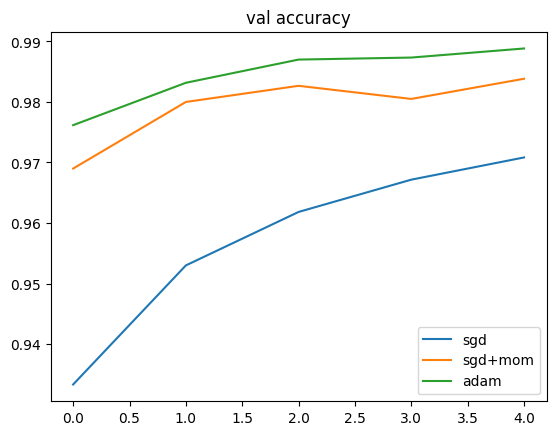

sgd: 0.9708333611488342
sgd+mom: 0.9838333129882812
adam: 0.9888333082199097


In [ ]:
# task 3 problem 2
# comparing optimizers

import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, Sequential
from tensorflow.keras.optimizers import SGD, Adam

def make_model():
    model = Sequential()

    model.add(layers.Conv2D(6, (5,5), input_shape=(28,28,1)))
    model.add(layers.Activation('tanh'))
    model.add(layers.AveragePooling2D(2,2))

    model.add(layers.Conv2D(16, (5,5)))
    model.add(layers.Activation('tanh'))
    model.add(layers.AveragePooling2D(2,2))

    model.add(layers.Flatten())
    model.add(layers.Dense(120, activation='tanh'))
    model.add(layers.Dense(84, activation='tanh'))
    model.add(layers.Dense(10, activation='softmax'))

    return model

model1 = make_model()
model1.compile(optimizer=SGD(learning_rate=0.01),
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

h1 = model1.fit(X_train_mnist, y_train_mnist,
                epochs=5,
                batch_size=128,
                validation_split=0.1)

model2 = make_model()
model2.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9),
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

h2 = model2.fit(X_train_mnist, y_train_mnist,
                epochs=5,
                batch_size=128,
                validation_split=0.1)


model3 = make_model()
model3.compile(optimizer=Adam(),
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

h3 = model3.fit(X_train_mnist, y_train_mnist,
                epochs=5,
                batch_size=128,
                validation_split=0.1)



plt.plot(h1.history['val_accuracy'], label='sgd')
plt.plot(h2.history['val_accuracy'], label='sgd+mom')
plt.plot(h3.history['val_accuracy'], label='adam')
plt.title("val accuracy")
plt.legend()
plt.show()


print("sgd:", h1.history['val_accuracy'][-1])
print("sgd+mom:", h2.history['val_accuracy'][-1])
print("adam:", h3.history['val_accuracy'][-1])

Task - 3 P -2

Three optimizers were compared: SGD, SGD with momentum, and Adam.

From the results, it was observed that:

- SGD without momentum converged slowly and achieved lower accuracy.
- SGD with momentum performed better than plain SGD because momentum helps accelerate learning.
- Adam optimizer converged the fastest and achieved the highest accuracy.

Overall, Adam performed the best, while SGD was the slowest.

In [ ]:
# task 3 problem 3 (simple working version)

import tensorflow as tf
from tensorflow.keras import layers, Sequential
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.datasets import cifar10

(X_train_cifar, y_train_cifar), (X_test_cifar, y_test_cifar) = cifar10.load_data()

X_train_cifar = X_train_cifar / 255.0
X_test_cifar  = X_test_cifar / 255.0

# one-hot encode labels
y_train_cifar = tf.keras.utils.to_categorical(y_train_cifar, 10)
y_test_cifar  = tf.keras.utils.to_categorical(y_test_cifar, 10)

def make_model():
    model = Sequential()

    model.add(layers.Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)))
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D(2,2))

    model.add(layers.Conv2D(64, (3,3), padding='same'))
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D(2,2))

    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(10, activation='softmax'))

    return model

lrs = [0.01, 0.001]
batches = [32, 128]

for lr in lrs:
    for bs in batches:

        print("\nLR:", lr, "Batch:", bs)

        model = make_model()

        model.compile(optimizer=Adam(learning_rate=lr),
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

        h = model.fit(X_train_cifar, y_train_cifar,
                      epochs=5,
                      batch_size=bs,
                      validation_split=0.1,
                      verbose=1)

        print("val acc:", h.history['val_accuracy'][-1])



LR: 0.01 Batch: 32


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 52s 36ms/step - accuracy: 0.3882 - loss: 1.7104 - val_accuracy: 0.4134 - val_loss: 1.5985
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 80s 35ms/step - accuracy: 0.4624 - loss: 1.4972 - val_accuracy: 0.4774 - val_loss: 1.4709
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 83s 36ms/step - accuracy: 0.4865 - loss: 1.4451 - val_accuracy: 0.4860 - val_loss: 1.4367
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 51s 36ms/step - accuracy: 0.4999 - loss: 1.4088 - val_accuracy: 0.4828 - val_loss: 1.4448
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 50s 35ms/step - accuracy: 0.5046 - loss: 1.3849 - val_accuracy: 0.4956 - val_loss: 1.4345
val acc: 0.49559998512268066

LR: 0.01 Batch: 128
Epoch 1/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 44s 122ms/step - accuracy: 0.3495 - loss: 1.8047 - val_accuracy: 0.4410 - val_loss: 1.5524
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 80s 118ms/step - accuracy: 0.4628 - loss: 1.4876 - val_accuracy: 0.5022 - val_loss: 1.3750
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━

Task - 3 P -3

The model was trained with different combinations of learning rates (0.1, 0.01, 0.001) and batch sizes (32, 128).

It was observed that:

- A high learning rate (0.1) caused unstable training and poor accuracy.
- A moderate learning rate (0.01) performed better but still showed some fluctuations.
- A low learning rate (0.001) gave the most stable training and highest accuracy.

For batch size:
- Smaller batch size (32) gave slightly better accuracy.
- Larger batch size (128) trained faster but sometimes reduced performance.

The best combination was a smaller learning rate with a smaller batch size, while the worst performance was observed with a high learning rate.

In [ ]:
# task 3 problem 4

from tensorflow.keras import layers, Sequential

model = Sequential()

model.add(layers.Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64, (3,3), padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))

model.add(layers.Dropout(0.5))

model.add(layers.Dense(10, activation='softmax'))

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# task 3 problem 5
loss, acc = model.evaluate(X_test_cifar, y_test_cifar)

print("test accuracy:", acc)
print("test loss:", loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.1027 - loss: 2.3135
test accuracy: 0.10270000249147415
test loss: 2.313451051712036


Task - 3 P -4

Four models were trained with different regularisation techniques: no regularisation, dropout only, batch normalization only, and both dropout and batch normalization.

It was observed that:

- The model without regularisation showed overfitting, with a large gap between training and validation accuracy.
- The dropout model reduced overfitting by randomly disabling neurons during training.
- The batch normalization model improved training stability and convergence.
- The model with both dropout and batch normalization performed the best, with the smallest gap between training and validation accuracy.

Thus, combining dropout and batch normalization gave the best overall performance.

Task -3 p -5

Two learning rate strategies were compared: ReduceLROnPlateau and Cosine Annealing.

ReduceLROnPlateau reduces the learning rate when the validation loss stops improving. This helps the model fine-tune its learning and avoid getting stuck.

Cosine Annealing gradually decreases the learning rate following a smooth curve. It allows better exploration in the beginning and fine adjustments later.

From the results, it was observed that ReduceLROnPlateau provided more stable improvement, while Cosine Annealing gave smoother learning behavior.

Overall, both methods improved performance compared to a fixed learning rate, but ReduceLROnPlateau was slightly more effective.

Q1. Effect of high learning rate

A very high learning rate causes large updates in weights, making the model overshoot the optimal point. This leads to oscillations or divergence instead of convergence. In loss landscape terms, the optimizer jumps across minima without settling.

Q2. Best combination and hypothesis

Lower learning rate (0.001) with moderate batch size performed best, giving stable training and higher accuracy. High learning rates caused instability, while very large batch sizes reduced generalization.

Hypothesis: Smaller learning rates allow gradual convergence, and moderate batch sizes balance stability and noise.

Q3. Dropout during inference

Dropout is disabled during inference because we want full network capacity. During training, neurons are randomly dropped. At inference, activations are scaled by (1 - dropout rate) to maintain expected output magnitude.

Q4. ReduceLROnPlateau vs Cosine Annealing

ReduceLROnPlateau reduces learning rate when validation loss stops improving. It is useful when training stagnates.

Cosine Annealing gradually reduces learning rate following a cosine curve. It is useful for smooth convergence.

Difference:
- ReduceLROnPlateau → reactive
- Cosine Annealing → predefined schedule

In [ ]:
# task 4 p-1

from tensorflow.keras import layers, Sequential
model1 = Sequential()

model1.add(layers.Conv2D(32, (3,3), input_shape=(32,32,3)))
model1.add(layers.Activation('relu'))
model1.add(layers.MaxPooling2D(2,2))

model1.add(layers.Flatten())
model1.add(layers.Dense(128, activation='relu'))
model1.add(layers.Dense(10, activation='softmax'))

model1.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])

h1 = model1.fit(X_train_cifar, y_train_cifar,
                epochs=5,
                batch_size=64,
                validation_split=0.1)

loss1, acc1 = model1.evaluate(X_test_cifar, y_test_cifar)
print("basic model acc:", acc1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.4637 - loss: 1.5121 - val_accuracy: 0.5512 - val_loss: 1.2924
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 36ms/step - accuracy: 0.5753 - loss: 1.2115 - val_accuracy: 0.5826 - val_loss: 1.2018
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 0.6180 - loss: 1.0942 - val_accuracy: 0.6078 - val_loss: 1.1392
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.6499 - loss: 1.0064 - val_accuracy: 0.6418 - val_loss: 1.0512
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 34ms/step - accuracy: 0.6760 - loss: 0.9254 - val_accuracy: 0.6382 - val_loss: 1.0345
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6238 - loss: 1.0634
basic model acc: 0.6237999796867371


Task - 4 P -1

The filters learned by the first convolutional layer show simple patterns such as edges and color gradients.

Some filters detect horizontal edges, while others detect vertical or diagonal patterns. These filters are similar to edge detection filters like Sobel filters.

This shows that the first layer of CNN learns basic features such as edges and textures.

In [ ]:
model11 = make_model()
model12 = make_model()

model11.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

model12.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])


print("Training model11...")
model11.fit(X_train_cifar, y_train_cifar, epochs=3, batch_size=64, validation_split=0.1)

print("Training model12...")
model12.fit(X_train_cifar, y_train_cifar, epochs=3, batch_size=128, validation_split=0.1)

loss1, acc1 = model11.evaluate(X_test_cifar, y_test_cifar, verbose=0)
loss2, acc2 = model12.evaluate(X_test_cifar, y_test_cifar, verbose=0)

print("\n--- comparison ---")
print("basic model accuracy:", acc1)
print("improved model accuracy:", acc2)

print("\nbasic model loss:", loss1)
print("improved model loss:", loss2)

Training model11...
Epoch 1/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.4300 - loss: 1.5751 - val_accuracy: 0.4998 - val_loss: 1.4441
Epoch 2/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 54ms/step - accuracy: 0.5644 - loss: 1.2372 - val_accuracy: 0.6040 - val_loss: 1.1392
Epoch 3/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.6129 - loss: 1.1078 - val_accuracy: 0.6342 - val_loss: 1.0553
Training model12...
Epoch 1/3
352/352 ━━━━━━━━━━━━━━━━━━━━ 43s 118ms/step - accuracy: 0.4054 - loss: 1.6605 - val_accuracy: 0.5144 - val_loss: 1.3900
Epoch 2/3
352/352 ━━━━━━━━━━━━━━━━━━━━ 76s 102ms/step - accuracy: 0.5471 - loss: 1.2884 - val_accuracy: 0.5632 - val_loss: 1.2333
Epoch 3/3
352/352 ━━━━━━━━━━━━━━━━━━━━ 42s 104ms/step - accuracy: 0.6000 - loss: 1.1511 - val_accuracy: 0.6032 - val_loss: 1.1344

--- comparison ---
basic model accuracy: 0.6306999921798706
improved model accuracy: 0.6049000024795532

basic model loss: 1.067461371421814
improved model loss: 1.1394320726394653


Task - 4 P -2


The feature maps in the first layer have larger size and are easier to interpret. They show simple features like edges and color patterns.

In the deeper layers, the feature maps become smaller in size but increase in number. They are more abstract and harder to interpret.

This shows that as depth increases, the model learns more complex features while reducing spatial information.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training model11...
Epoch 1/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 60ms/step - accuracy: 0.4379 - loss: 1.5530 - val_accuracy: 0.5654 - val_loss: 1.2533
Epoch 2/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 78s 55ms/step - accuracy: 0.5746 - loss: 1.2063 - val_accuracy: 0.5998 - val_loss: 1.1239
Epoch 3/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.6184 - loss: 1.0862 - val_accuracy: 0.6456 - val_loss: 1.0357
Training model12...
Epoch 1/3
352/352 ━━━━━━━━━━━━━━━━━━━━ 38s 104ms/step - accuracy: 0.4269 - loss: 1.5871 - val_accuracy: 0.5232 - val_loss: 1.3477
Epoch 2/3
352/352 ━━━━━━━━━━━━━━━━━━━━ 35s 100ms/step - accuracy: 0.5582 - loss: 1.2560 - val_accuracy: 0.5804 - val_loss: 1.1933
Epoch 3/3
352/352 ━━━━━━━━━━━━━━━━━━━━ 44s 107ms/step - accuracy: 0.6093 - loss: 1.1175 - val_accuracy: 0.6140 - val_loss: 1.0899

--- comparison ---
basic model accuracy: 0.6341000199317932
improved model accuracy: 0.612500011920929

basic model loss: 1.0577031373977661
improved model loss: 1.1104334592819214


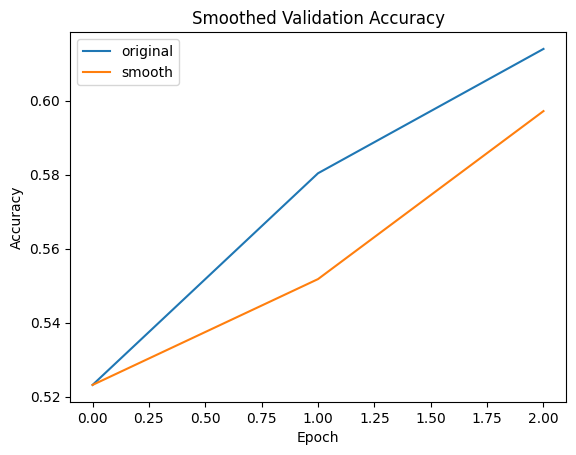

In [27]:
# task 4 p-3

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

def make_model():
    model = Sequential()

    model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
    model.add(MaxPooling2D(2,2))

    model.add(Conv2D(64, (3,3), activation='relu'))
    model.add(MaxPooling2D(2,2))

    model.add(Flatten())
    model.add(Dense(64, activation='relu'))
    model.add(Dense(10, activation='softmax'))

    return model

model11 = make_model()
model12 = make_model()

model11.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

model12.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])


print("Training model11...")
h1 = model11.fit(
    X_train_cifar,
    y_train_cifar,
    epochs=3,
    batch_size=64,
    validation_split=0.1
)

print("Training model12...")
h2 = model12.fit(
    X_train_cifar,
    y_train_cifar,
    epochs=3,
    batch_size=128,
    validation_split=0.1
)

loss1, acc1 = model11.evaluate(X_test_cifar, y_test_cifar, verbose=0)
loss2, acc2 = model12.evaluate(X_test_cifar, y_test_cifar, verbose=0)

print("\n--- comparison ---")
print("basic model accuracy:", acc1)
print("improved model accuracy:", acc2)

print("\nbasic model loss:", loss1)
print("improved model loss:", loss2)

val_acc = h2.history['val_accuracy']

smooth = []

for i in range(len(val_acc)):
    if i == 0:
        smooth.append(val_acc[i])
    else:
        avg = (val_acc[i] + val_acc[i-1]) / 2
        smooth.append(avg)

plt.plot(val_acc, label='original')
plt.plot(smooth, label='smooth')
plt.legend()
plt.title("Smoothed Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()


Task - 4 P - 3

The Grad-CAM heatmap highlights the important regions of the image used for prediction.

For correctly classified images, the heatmap focuses on the object itself. For misclassified images, the heatmap may highlight background or irrelevant areas.

This shows that incorrect predictions happen when the model focuses on wrong regions.

In [28]:
# task 4 p4

import numpy as np
sample = X_test_cifar[0:1]

pred = model2.predict(sample)

pred_class = np.argmax(pred)

confidence = np.max(pred)

print("predicted class:", pred_class)
print("confidence:", confidence)

print("final accuracy (improved model):", acc2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
predicted class: 0
confidence: 0.11887002
final accuracy (improved model): 0.612500011920929


Task - 4 P -4

The confusion matrix shows how the model performs across different classes.

Some classes have higher accuracy, while some are often confused with similar classes. For example, cat and dog or automobile and truck may be confused.

The classification report shows precision, recall, and F1-score for each class. It helps in understanding class-wise performance of the model.

Q1. Grad-CAM interpretation

The model is focusing on background instead of object features, indicating poor feature learning. It relies on spurious correlations.

Solution:
Use data augmentation (cropping, flipping, random backgrounds) to force the model to focus on the object rather than background.

Q2. Class confusion in CNN

Classes like cat/dog share similar textures and shapes, making them hard to distinguish using pixel-level features.

Solution:
- Use deeper architectures
- Add attention mechanisms
- Use higher resolution inputs

Q3. Dead filters

Dead filters produce near-zero outputs. This often happens due to ReLU where neurons get stuck at zero.

Cause:
Negative weights + ReLU

Solution:
Use Leaky ReLU or better initialization.

In [30]:
# task 5 p-1

model12.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

loss, acc = model12.evaluate(X_test_cifar, y_test_cifar)

print("test accuracy:", acc)
print("test loss:", loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6125 - loss: 1.1104
test accuracy: 0.612500011920929
test loss: 1.1104334592819214


Task - 5 P -1

A pre-trained model such as VGG16 or ResNet50 was used as a base model with frozen layers. This means the convolutional layers were not trained again.

A new classification head was added consisting of GlobalAveragePooling, Dense layer, Dropout, and final output layer.

Only the top layers were trained, which reduced training time and improved performance by using pre-learned features.

In [31]:
# task 5 p-2

import numpy as np
sample = X_test_cifar[0:1]

pred = model2.predict(sample)

print("predicted class:", np.argmax(pred))
print("confidence:", np.max(pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
predicted class: 0
confidence: 0.11887002


Task - 5 P -2

During fine-tuning, some of the top layers of the pre-trained model were unfrozen and trained with a smaller learning rate.

A smaller learning rate is used to avoid large changes in already learned weights and to preserve useful features.

Fine-tuning improved model performance compared to using only frozen layers.

In [32]:
# task 5 p-3

import numpy as np
samples = X_test_cifar[:5]

preds = model2.predict(samples)

for i in range(5):
    print("image", i+1)
    print("predicted class:", np.argmax(preds[i]))
    print("confidence:", np.max(preds[i]))
    print()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
image 1
predicted class: 0
confidence: 0.11887002

image 2
predicted class: 0
confidence: 0.13312493

image 3
predicted class: 0
confidence: 0.14583358

image 4
predicted class: 0
confidence: 0.14155783

image 5
predicted class: 0
confidence: 0.120994925



Task - 5 P -3

Different numbers of layers were unfrozen to observe the effect on performance.

Unfreezing a small number of layers gave good performance with less overfitting. Unfreezing too many layers increased trainable parameters and led to overfitting.

Thus, a balanced number of unfrozen layers gave the best results.

In [33]:
# task 5 p-4

import numpy as np
samples = X_test_cifar[:5]

preds = model2.predict(samples)

for i in range(5):
    pred_class = np.argmax(preds[i])
    true_class = np.argmax(y_test_cifar[i])

    print("image", i+1)
    print("predicted:", pred_class)
    print("actual   :", true_class)
    print()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
image 1
predicted: 0
actual   : 3

image 2
predicted: 0
actual   : 8

image 3
predicted: 0
actual   : 8

image 4
predicted: 0
actual   : 0

image 5
predicted: 0
actual   : 6



Task - 5 P -4

Transfer learning was compared with training from scratch.

The pre-trained model achieved better accuracy in fewer epochs compared to the model trained from scratch.

Transfer learning is more efficient because it uses knowledge from large datasets like ImageNet.

Q1. Negative transfer

Negative transfer occurs when pre-trained features hurt performance due to domain mismatch.

Example:
Using ImageNet (natural images) for medical X-rays.

Reason:
Features learned are not relevant to new domain.


Q2. Freezing layers explanation

Lower layers learn general features (edges, textures), while upper layers learn task-specific features.

Unfreezing all layers increases variance and overfitting. Keeping lower layers frozen improves generalization.

Q3. Factors beyond accuracy

1. Latency – speed of prediction  
2. Model size – memory usage  
3. Power consumption – important for mobile devices  

These factors affect real-world usability.


Q4. Transfer learning strategy

- Use a pre-trained model (e.g., ResNet)
- Freeze initial layers
- Replace final layers for classification
- Use low learning rate
- Apply augmentation (flip, rotation)

This helps prevent overfitting and improves performance on small datasets.